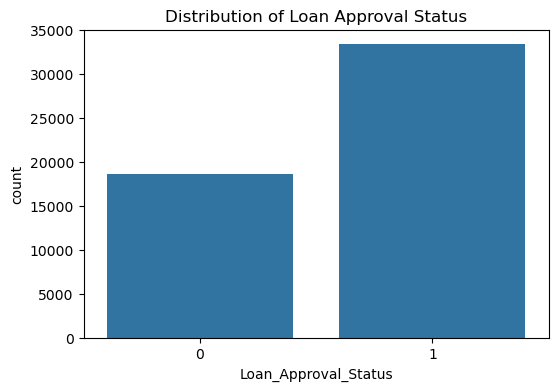

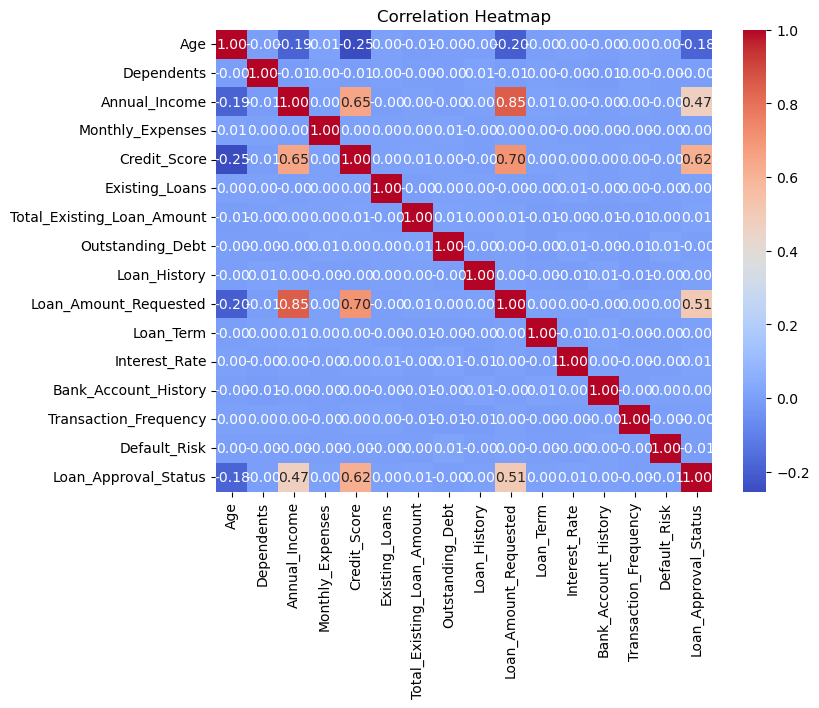

--- Random Forest Model Performance ---
Accuracy Score: 0.8558

Confusion Matrix:
[[2549 1054]
 [ 446 6351]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.71      0.77      3603
           1       0.86      0.93      0.89      6797

    accuracy                           0.86     10400
   macro avg       0.85      0.82      0.83     10400
weighted avg       0.86      0.86      0.85     10400



In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ---------------------------------------------------------
# Step 1: Data Collection & Pre-processing (10 Marks)
# ---------------------------------------------------------
# Load the dataset
df = pd.read_csv('Loan_Dataset.csv')

# Drop the unique identifier as it has no predictive value
df = df.drop('Applicant_ID', axis=1)

plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Approval_Status', data=df)
plt.title('Distribution of Loan Approval Status')
plt.show()

# Quick heatmap to see correlations between numerical features
numerical_cols = df.select_dtypes(include=[np.number])
plt.figure(figsize=(8,6))
sns.heatmap(numerical_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# Handle Missing Values (Good practice, even if your current sample looks clean)
# Fill categorical columns with the mode
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])
    
# Fill numerical columns with the median
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())

# ---------------------------------------------------------
# Step 2: Innovation / Creativity in Approach (5 Marks)
# ---------------------------------------------------------
# Feature Engineering: Calculate the Debt-to-Income (DTI) Ratio
# DTI is a crucial metric used by real banks to assess risk
df['Monthly_Income'] = df['Annual_Income'] / 12
df['DTI_Ratio'] = df['Monthly_Expenses'] / df['Monthly_Income']
df = df.drop('Monthly_Income', axis=1) # Drop temporary column

# ---------------------------------------------------------
# Step 3: Encoding Categorical Variables
# ---------------------------------------------------------
# 3a. Label Encoding for binary categories (2 options)
binary_cols = ['Gender', 'Marital_Status', 'Education', 'Loan_Type', 'Co-Applicant']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# 3b. One-Hot Encoding for nominal categories (3+ options)
# drop_first=True prevents the "dummy variable trap" (multicollinearity)
nominal_cols = ['Employment_Status', 'Occupation_Type', 'Residential_Status', 'City/Town', 'Loan_Purpose']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

# ---------------------------------------------------------
# Step 4: Model Development & Implementation (12 Marks)
# ---------------------------------------------------------
# Separate features (X) and target variable (y)
X = df.drop('Loan_Approval_Status', axis=1)
y = df['Loan_Approval_Status']

# Train/Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling: Standardize the data so large values (Income) 
# don't overpower small values (Interest Rate)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predict on the hidden test set
y_pred = rf_model.predict(X_test_scaled)

# ---------------------------------------------------------
# Step 5: Performance Evaluation (8 Marks)
# ---------------------------------------------------------
print("--- Random Forest Model Performance ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

In [37]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC # Import Support Vector Classifier
import numpy as np

# 1. Separate features (X) and target variable (y)
X = df.drop('Loan_Approval_Status', axis=1)
y = df['Loan_Approval_Status']

# 2. Add SVM (SVC) to your models dictionary
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(kernel='rbf', random_state=42) # Added SVM here
}

# 3. Setup Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring_metrics = ['accuracy', 'f1']

# 4. Loop through models and cross-validate
for name, model in models.items():
    print(f"==================================================")
    print(f"--- {name} ---")
    
    # The Pipeline guarantees StandardScaler runs inside each fold perfectly
    pipeline = make_pipeline(StandardScaler(), model)
    cv_results = cross_validate(pipeline, X, y, cv=skf, scoring=scoring_metrics)
    
    acc_scores = cv_results['test_accuracy']
    f1_scores = cv_results['test_f1']
    
    print(f"Mean Accuracy: {np.mean(acc_scores):.4f} (+/- {np.std(acc_scores):.4f})")
    print(f"Mean F1-Score: {np.mean(f1_scores):.4f} (+/- {np.std(f1_scores):.4f})\n")
    
print(f"==================================================")

--- Logistic Regression ---
Mean Accuracy: 0.8491 (+/- 0.0028)
Mean F1-Score: 0.8879 (+/- 0.0021)

--- Decision Tree ---
Mean Accuracy: 0.7258 (+/- 0.0039)
Mean F1-Score: 0.7843 (+/- 0.0035)

--- Random Forest ---
Mean Accuracy: 0.8500 (+/- 0.0031)
Mean F1-Score: 0.8884 (+/- 0.0022)

--- Support Vector Machine ---
Mean Accuracy: 0.8479 (+/- 0.0030)
Mean F1-Score: 0.8871 (+/- 0.0022)

